# Telecom X — Parte 2: Prevendo Churn com Machine Learning

**Programa:** Alura ONE G9 | Tech Foundation · Especialização Data Science  
**Dataset:** `dados_tratados.csv` (gerado na Parte 1 do desafio)  
**Objetivo:** Construir modelos preditivos para prever a evasão (churn) de clientes da Telecom X.

---

## 📋 Sumário
1. Importação de Bibliotecas
2. Carregamento dos Dados Tratados
3. Pré-processamento (limpeza, agrupamentos, encoding)
4. Análise Exploratória (EDA): Correlação e Seleção de Variáveis
5. Separação Treino / Teste
6. Treinamento dos Modelos Preditivos
7. Avaliação e Comparação dos Modelos
8. Interpretação e Importância das Variáveis
9. Conclusão Estratégica

#1.Importação de Bibliotecas

In [156]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import chi2
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

import warnings
warnings.filterwarnings('ignore')

print('✅ Bibliotecas importadas com sucesso!')

✅ Bibliotecas importadas com sucesso!


In [157]:
url = "https://drive.google.com/uc?export=download&id=17rakBBHlWvQiC-zHe9LDI2sKvf42kLtG"

df = pd.read_csv(url)

#2. Carregamento dos Dados Tratados


In [158]:
df.head()

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


In [159]:
df.tail()

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
7038,9987-LUTYD,No,Female,No,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,1.84,55.15,742.90
7039,9992-RRAMN,Yes,Male,No,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,2.84,85.10,1873.70
7040,9992-UJOEL,No,Male,No,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,1.68,50.30,92.75
7041,9993-LHIEB,No,Male,No,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,2.26,67.85,4627.65
7042,9995-HOTOH,No,Male,No,Yes,Yes,63,No,No,DSL,...,Yes,No,Yes,Yes,Two year,No,Electronic check,1.97,59.00,3707.60


In [160]:
df.shape

(7043, 22)

In [161]:
df.columns

Index(['CustomerID', 'Churn', 'Gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'Tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'ChargesDaily', 'ChargesMonthly',
       'ChargesTotal'],
      dtype='object')

In [162]:
df.describe(include='all')

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
count,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043.000000,7043.000000
unique,7043,2,2,2,2,2,NaN,2,2,3,...,2,2,2,2,3,2,4,NaN,NaN,NaN
top,9995-HOTOH,No,Male,No,No,No,NaN,Yes,No,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,NaN,NaN
freq,1,5174,3555,5901,3641,4933,NaN,6361,4072,3096,...,4621,4999,4336,4311,3875,4171,2365,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,32.371149,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.158675,64.761692,2279.734304
std,NaN,NaN,NaN,NaN,NaN,NaN,24.559481,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.003088,30.090047,2266.794470
min,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.610000,18.250000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,9.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.180000,35.500000,398.550000
50%,NaN,NaN,NaN,NaN,NaN,NaN,29.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.340000,70.350000,1394.550000
75%,NaN,NaN,NaN,NaN,NaN,NaN,55.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.990000,89.850000,3786.600000


In [163]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


In [164]:
df.isnull().sum()

,0
CustomerID,0
Churn,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


# 3. Pré-processamento (limpeza, agrupamentos, encoding)

##3.1 Removendo Colunas Irrelevantes

In [165]:
#`CustomerID` é um identificador único sem valor preditivo — sua presença prejudica os modelos.
#As colunas `ChargesDaily` e `ChargesTotal` serão avaliadas pela correlação antes de serem removidas.

df = df.drop(columns=['CustomerID'])
print('✅ CustomerID removido.')
print(f'Shape: {df.shape}')

✅ CustomerID removido.
Shape: (7043, 21)


##3.2 Agrupamento de 'No internet service' → 'No'

In [166]:
cols_to_fix = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in cols_to_fix:
    df[col] = df[col].replace('No internet service', 'No')

print('✅ Agrupamento realizado.')
print('Valores únicos em OnlineSecurity:', df['OnlineSecurity'].unique())

✅ Agrupamento realizado.
Valores únicos em OnlineSecurity: ['No' 'Yes']


In [167]:
df

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,No,Female,No,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.60,593.30
1,No,Male,No,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.90,542.40
2,Yes,Male,No,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.90,280.85
3,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.00,1237.85
4,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,No,Female,No,No,No,13,Yes,No,DSL,Yes,...,No,Yes,No,No,One year,No,Mailed check,1.84,55.15,742.90
7039,Yes,Male,No,Yes,No,22,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,2.84,85.10,1873.70
7040,No,Male,No,No,No,2,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,1.68,50.30,92.75
7041,No,Male,No,Yes,Yes,67,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,Two year,No,Mailed check,2.26,67.85,4627.65


##3.3 Verificação de Valores Nulos

In [168]:
nulos = df.isnull().sum()
print('Valores nulos por coluna:')
print(nulos[nulos > 0] if nulos.sum() > 0 else '✅ Nenhum valor nulo encontrado!')

Valores nulos por coluna:
✅ Nenhum valor nulo encontrado!


##3.4 Encoding

In [169]:
df_encoded = pd.get_dummies(df, drop_first=True)


In [170]:
df_encoded.head()

,Tenure,ChargesDaily,ChargesMonthly,ChargesTotal,Churn_Yes,Gender_Male,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,9,2.19,65.6,593.30,False,False,False,True,True,True,...,False,True,True,False,True,False,True,False,False,True
1,9,2.00,59.9,542.40,False,True,False,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,4,2.46,73.9,280.85,True,True,False,False,False,True,...,True,False,False,False,False,False,True,False,True,False
3,13,3.27,98.0,1237.85,True,True,True,True,False,True,...,True,False,True,True,False,False,True,False,True,False
4,3,2.80,83.9,267.40,True,False,True,True,False,True,...,False,True,True,False,False,False,True,False,False,True


##3.5 Verificando proporção do Churn:

In [171]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [172]:
df_encoded['Churn_Yes'].value_counts(normalize=True)

,proportion
Churn_Yes,
False,0.73463
True,0.26537


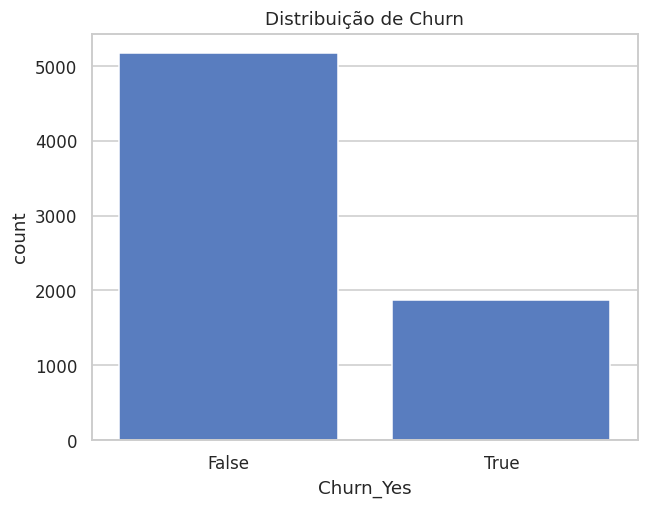

In [173]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df_encoded['Churn_Yes'])
plt.title("Distribuição de Churn")
plt.show()

#4. Análise Exploratória (EDA): Correlação e Seleção de Variáveis

##4.1 Proporção de Churn (Verificação do Desbalanceamento)

Contagem:
Churn
No     5174
Yes    1869

Proporção (%):
Churn
No     73.46
Yes    26.54


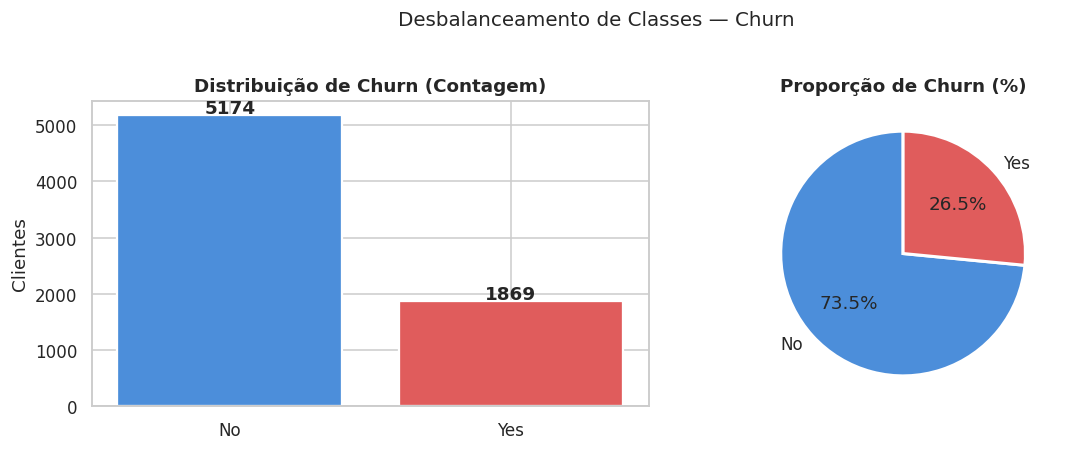


⚠️  Dataset desbalanceado (~73% Não / ~27% Sim).
   Avaliaremos os modelos priorizando Recall, F1-Score e AUC-ROC.


In [174]:
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

print('Contagem:')
print(churn_counts.to_string())
print('\nProporção (%):')
print(churn_pct.round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
cores = ['#4C8EDA', '#E05C5C']

axes[0].bar(churn_counts.index, churn_counts.values, color=cores, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribuição de Churn (Contagem)', fontweight='bold')
axes[0].set_ylabel('Clientes')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 40, str(v), ha='center', fontweight='bold')

axes[1].pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%',
            colors=cores, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporção de Churn (%)', fontweight='bold')

plt.suptitle('Desbalanceamento de Classes — Churn', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('\n⚠️  Dataset desbalanceado (~73% Não / ~27% Sim).')
print('   Avaliaremos os modelos priorizando Recall, F1-Score e AUC-ROC.')

##4.2 Correlação entre Variáveis Numéricas

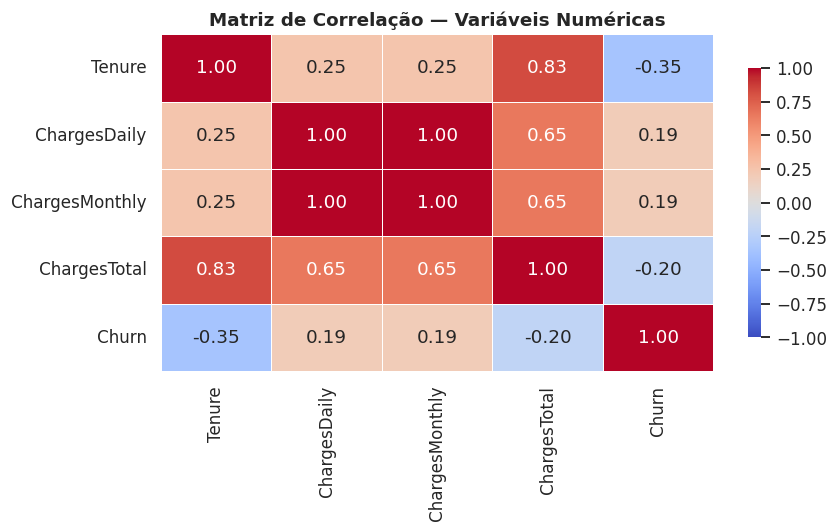


📌 Insights:
  • Tenure (tempo de contrato) tem correlação NEGATIVA com Churn:
    clientes mais antigos evadem menos.
  • ChargesMonthly tem correlação POSITIVA com Churn:
    cobranças mensais mais altas estão associadas a maior evasão.
  • ChargesDaily e ChargesTotal são derivadas de ChargesMonthly — alta multicolinearidade.
    → Removeremos ChargesDaily e ChargesTotal para evitar redundância.


In [175]:
# Criar cópia com Churn numérico para a correlação
df_numeric = df.select_dtypes(include=['int64', 'float64']).copy()
df_numeric['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

corr_matrix = df_numeric.corr()

plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, vmin=-1, vmax=1, center=0,
            cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlação — Variáveis Numéricas', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n📌 Insights:')
print('  • Tenure (tempo de contrato) tem correlação NEGATIVA com Churn:')
print('    clientes mais antigos evadem menos.')
print('  • ChargesMonthly tem correlação POSITIVA com Churn:')
print('    cobranças mensais mais altas estão associadas a maior evasão.')
print('  • ChargesDaily e ChargesTotal são derivadas de ChargesMonthly — alta multicolinearidade.')
print('    → Removeremos ChargesDaily e ChargesTotal para evitar redundância.')

In [176]:
# Remover colunas redundantes (alta multicolinearidade com ChargesMonthly)
df = df.drop(columns=['ChargesDaily', 'ChargesTotal'])
print('✅ ChargesDaily e ChargesTotal removidas.')
print(f'Shape: {df.shape}')

✅ ChargesDaily e ChargesTotal removidas.
Shape: (7043, 19)


##4.3 Análise de Churn por Variáveis Categóricas (Qui-quadrado)

In [177]:
# Separar variáveis categóricas (excluindo Churn)
categorical_cols = df.select_dtypes(include=['object']).columns
categorical_cols = categorical_cols.drop('Churn')



In [178]:
# Visualização: proporção de churn por categoria
print('📊 Proporção de Churn por variável categórica (%):\n')
for col in categorical_cols:
    crosstab = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    display(crosstab.round(2))

📊 Proporção de Churn por variável categórica (%):



Churn,No,Yes
Gender,,
Female,73.08,26.92
Male,73.84,26.16


Churn,No,Yes
SeniorCitizen,,
No,76.39,23.61
Yes,58.32,41.68


Churn,No,Yes
Partner,,
No,67.04,32.96
Yes,80.34,19.66


Churn,No,Yes
Dependents,,
No,68.72,31.28
Yes,84.55,15.45


...

Churn,No,Yes
StreamingTV,,
No,75.67,24.33
Yes,69.93,30.07


Churn,No,Yes
StreamingMovies,,
No,75.62,24.38
Yes,70.06,29.94


Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


Churn,No,Yes
PaperlessBilling,,
No,83.67,16.33
Yes,66.43,33.57


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


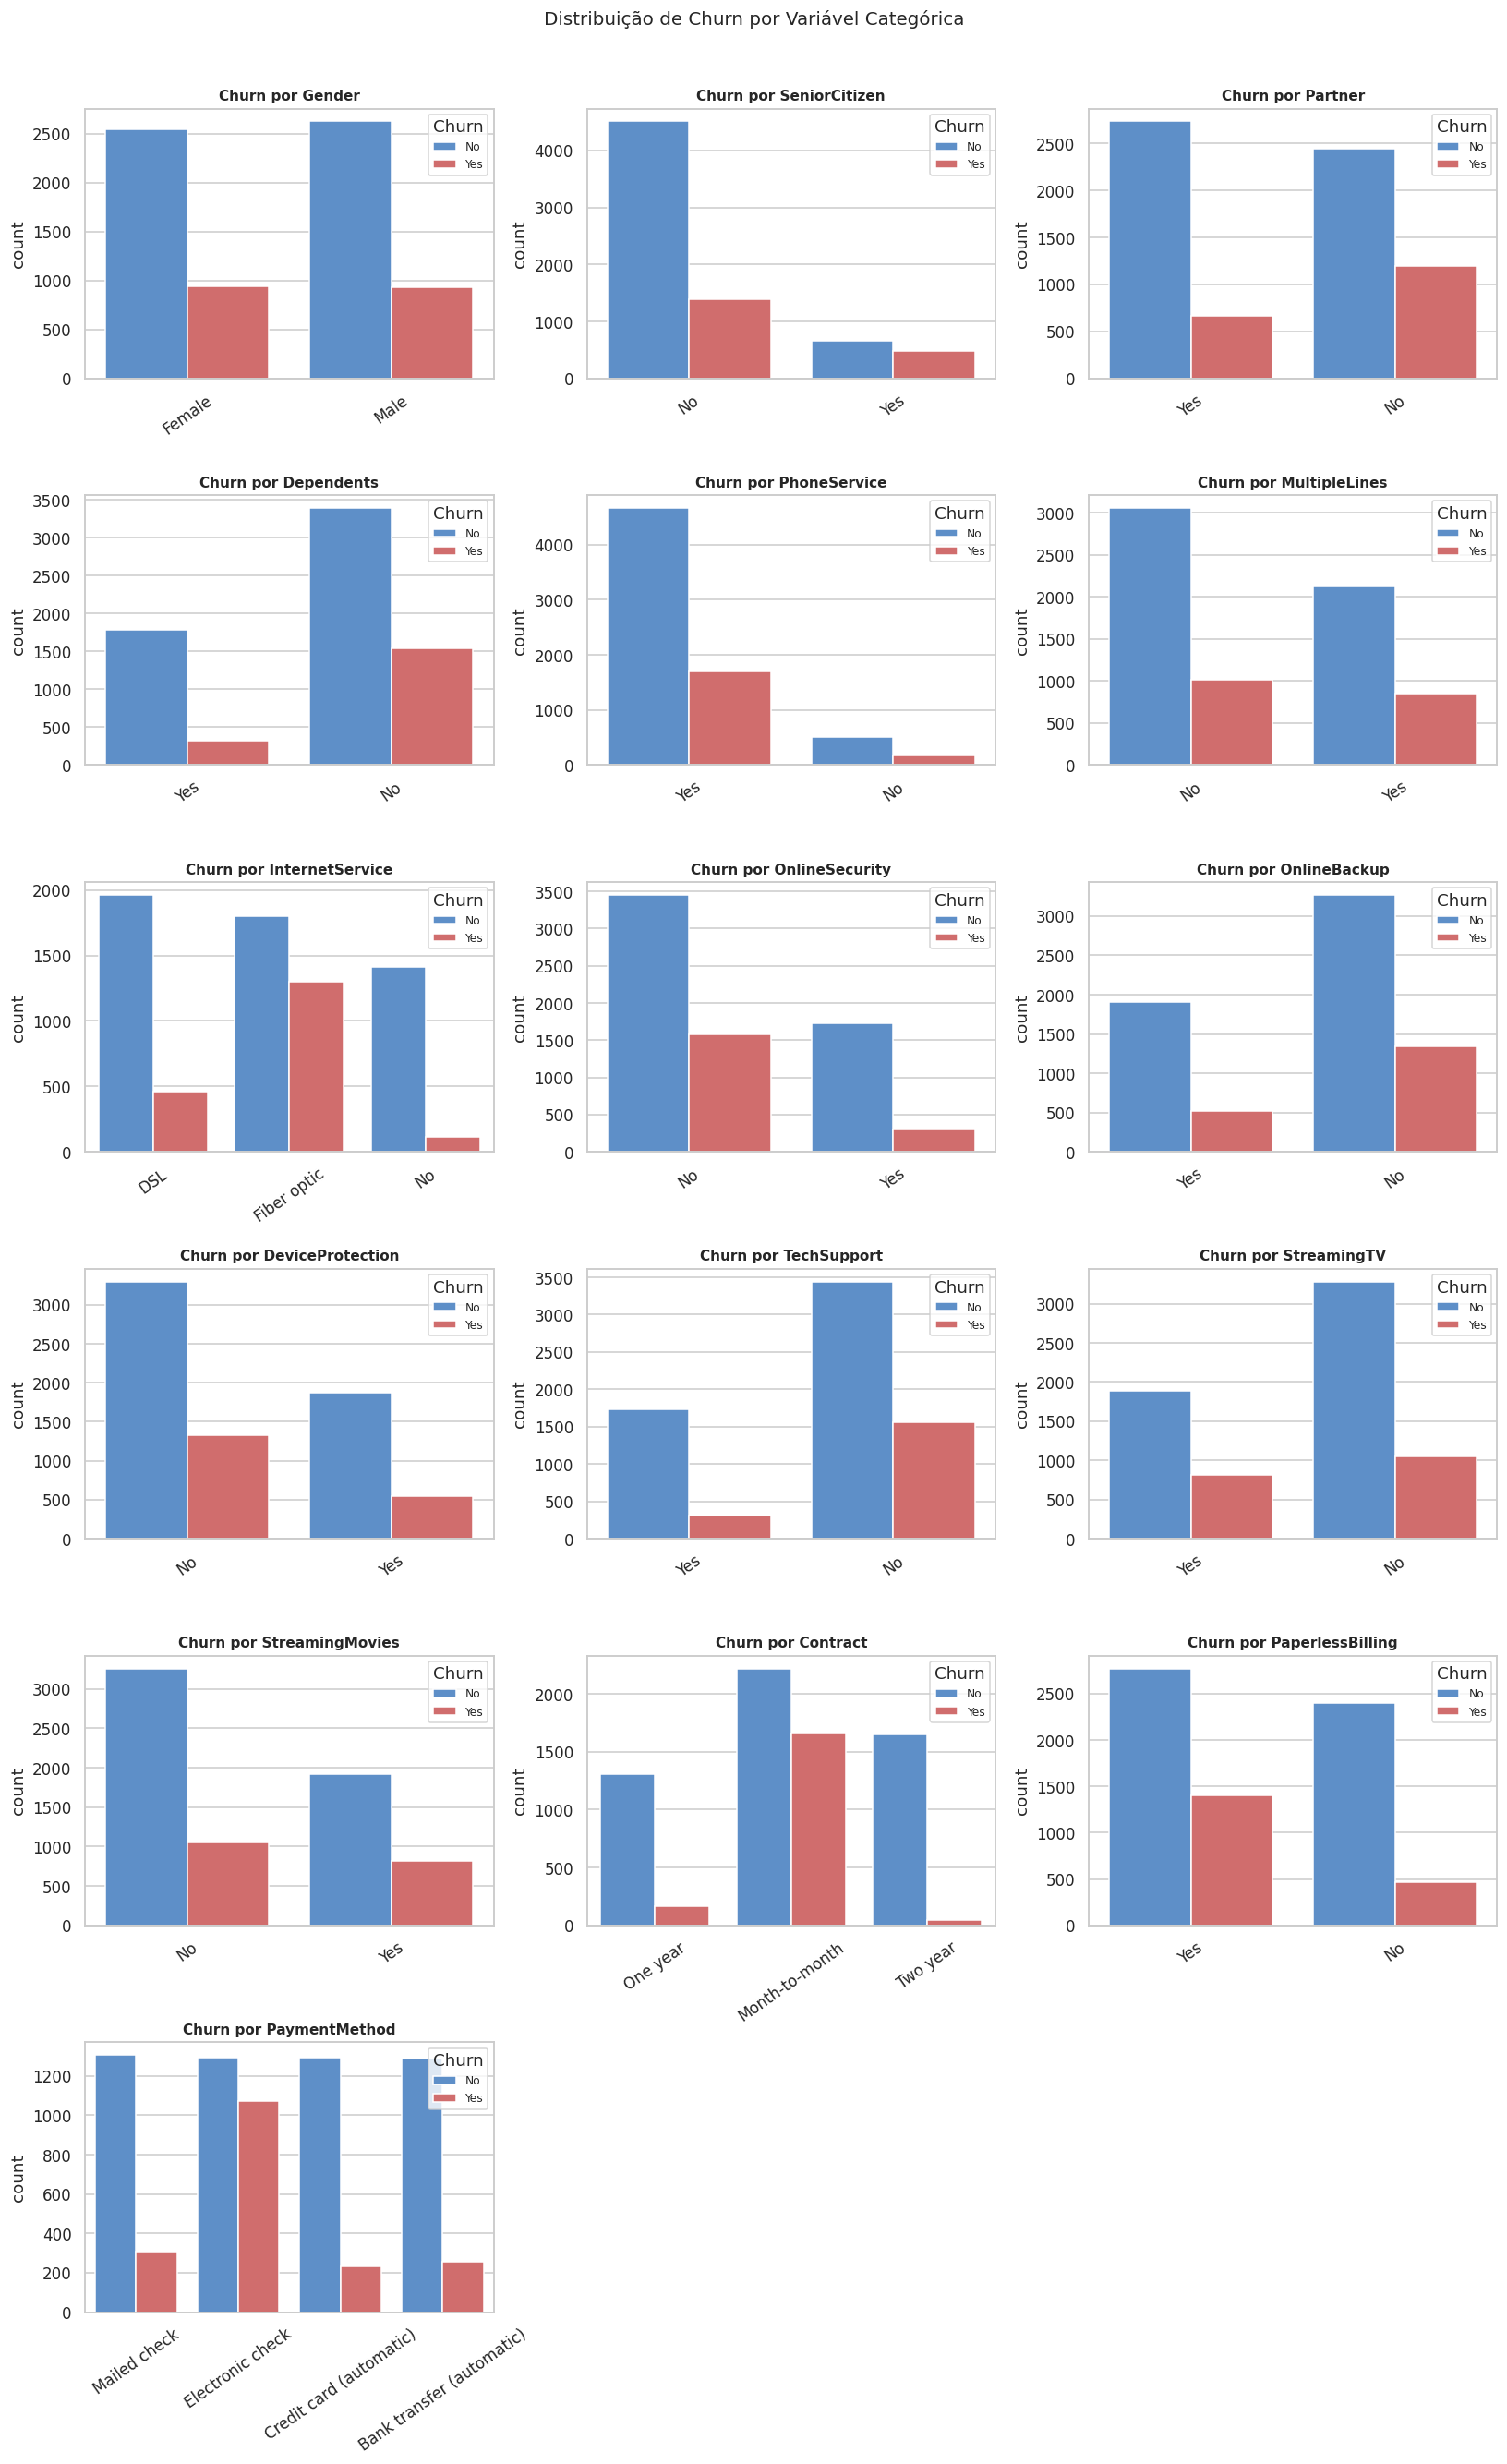

In [179]:
# Gráficos de distribuição por variável categórica
fig_cols = 3
fig_rows = -(-len(categorical_cols) // fig_cols)  # ceil division
fig, axes = plt.subplots(fig_rows, fig_cols, figsize=(15, fig_rows * 4))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, hue='Churn',
                  palette=['#4C8EDA', '#E05C5C'], ax=axes[i], edgecolor='white')
    axes[i].set_title(f'Churn por {col}', fontweight='bold', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=35)
    axes[i].legend(title='Churn', fontsize=8)

# Remover subplots extras
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribuição de Churn por Variável Categórica', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [180]:
# Teste Qui-quadrado para selecionar variáveis categóricas significativas
df_rank = df.copy()
df_rank['Churn'] = df_rank['Churn'].map({'Yes': 1, 'No': 0})

cat_cols_rank = df_rank.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in cat_cols_rank:
    df_rank[col] = le.fit_transform(df_rank[col])

X_cat = df_rank[cat_cols_rank]
y_chi = df_rank['Churn']

chi_scores, p_values = chi2(X_cat, y_chi)

chi_df = pd.DataFrame({
    'Variável': cat_cols_rank,
    'Chi²': chi_scores,
    'p-value': p_values
}).sort_values('p-value')

print('📋 Resultado do Teste Qui-quadrado (variáveis categóricas):')
display(chi_df.round(6))

print('\n✅ Variáveis significativas (p < 0.05):')
significant_vars = chi_df[chi_df['p-value'] < 0.05]
display(significant_vars)

print('\n❌ Variáveis NÃO significativas (p ≥ 0.05) — candidatas à remoção:')
not_significant = chi_df[chi_df['p-value'] >= 0.05]
display(not_significant)

📋 Resultado do Teste Qui-quadrado (variáveis categóricas):


,Variável,Chi²,p-value
13,Contract,1115.780167,0.000000
7,OnlineSecurity,147.295858,0.000000
10,TechSupport,135.559783,0.000000
1,SeniorCitizen,134.351545,0.000000
3,Dependents,133.036443,0.000000
14,PaperlessBilling,105.680863,0.000000
2,Partner,82.412083,0.000000
15,PaymentMethod,58.492250,0.000000
8,OnlineBackup,31.217694,0.000000
9,DeviceProtection,20.226662,0.000007



✅ Variáveis significativas (p < 0.05):


,Variável,Chi²,p-value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06



❌ Variáveis NÃO significativas (p ≥ 0.05) — candidatas à remoção:


,Variável,Chi²,p-value
0,Gender,0.258699,0.611016
4,PhoneService,0.097261,0.755142


In [181]:
# Gender e PhoneService não são estatisticamente significativos (p ≥ 0.05)
# → Removemos para simplificar o modelo e reduzir ruído

df = df.drop(columns=['Gender', 'PhoneService'])
print('✅ Gender e PhoneService removidos.')
print(f'Shape final: {df.shape}')
print(f'Colunas: {list(df.columns)}')

✅ Gender e PhoneService removidos.
Shape final: (7043, 17)
Colunas: ['Churn', 'SeniorCitizen', 'Partner', 'Dependents', 'Tenure', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'ChargesMonthly']


##4.4 Análises Direcionadas: Tenure × Churn e ChargesMonthly × Churn

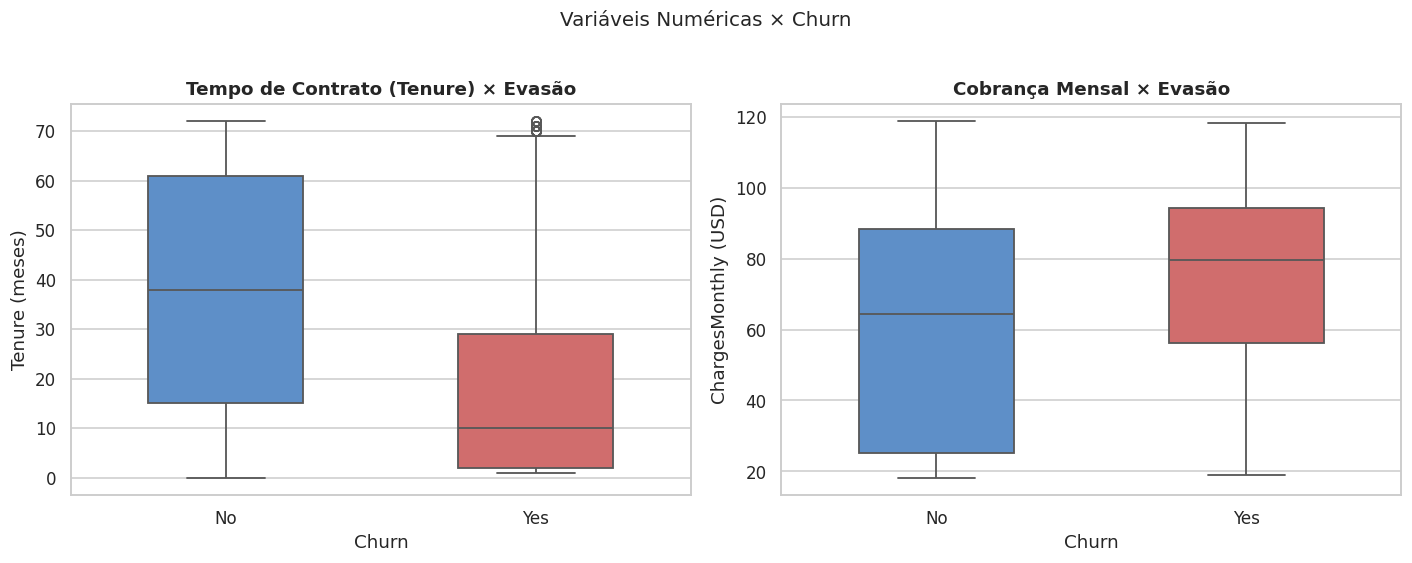

📌 Insights:
  • Clientes que evadem têm MENOR tempo de contrato (Tenure mediana menor).
  • Clientes que evadem têm MAIOR cobrança mensal (ChargesMonthly mediana maior).


In [182]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x='Churn', y='Tenure',
            palette=['#4C8EDA', '#E05C5C'], ax=axes[0], width=0.5, linewidth=1.2)
axes[0].set_title('Tempo de Contrato (Tenure) × Evasão', fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Tenure (meses)')

sns.boxplot(data=df, x='Churn', y='ChargesMonthly',
            palette=['#4C8EDA', '#E05C5C'], ax=axes[1], width=0.5, linewidth=1.2)
axes[1].set_title('Cobrança Mensal × Evasão', fontweight='bold')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('ChargesMonthly (USD)')

plt.suptitle('Variáveis Numéricas × Churn', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('📌 Insights:')
print('  • Clientes que evadem têm MENOR tempo de contrato (Tenure mediana menor).')
print('  • Clientes que evadem têm MAIOR cobrança mensal (ChargesMonthly mediana maior).')

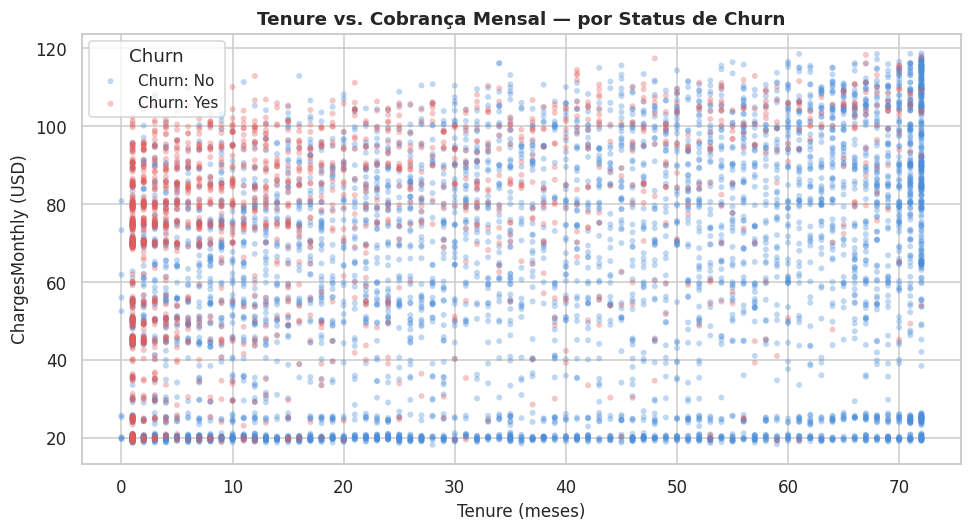

📌 Clientes com alto ChargesMonthly e baixo Tenure concentram maior evasão.


In [183]:
# Scatter: Tenure vs ChargesMonthly colorido por Churn
fig, ax = plt.subplots(figsize=(9, 5))
cores_map = {'No': '#4C8EDA', 'Yes': '#E05C5C'}
for churn_val, cor in cores_map.items():
    subset = df[df['Churn'] == churn_val]
    ax.scatter(subset['Tenure'], subset['ChargesMonthly'],
               c=cor, label=f'Churn: {churn_val}', alpha=0.35, s=15, edgecolors='none')

ax.set_xlabel('Tenure (meses)', fontsize=11)
ax.set_ylabel('ChargesMonthly (USD)', fontsize=11)
ax.set_title('Tenure vs. Cobrança Mensal — por Status de Churn', fontsize=12, fontweight='bold')
ax.legend(title='Churn', fontsize=10)
plt.tight_layout()
plt.show()

print('📌 Clientes com alto ChargesMonthly e baixo Tenure concentram maior evasão.')

#5. Separação Treino / Teste

**Importante:** o One-Hot Encoding é aplicado **após** o split para evitar *data leakage*.

In [184]:
# 1. Separar X e y
X = df.drop('Churn', axis=1)
y = df['Churn']

# 2. Split estratificado (80% treino / 20% teste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f'Total:  {len(X)} registros')
print(f'Treino: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)')
print(f'Teste:  {len(X_test)}  ({len(X_test)/len(X)*100:.1f}%)')

Total:  7043 registros
Treino: 5634 (80.0%)
Teste:  1409  (20.0%)


In [185]:
# 3. Verificar desbalanceamento no conjunto de treino
print('Proporção de Churn no treino:')
print((y_train.value_counts(normalize=True) * 100).round(2))
print()
print('Proporção de Churn no teste:')
print((y_test.value_counts(normalize=True) * 100).round(2))

print()
print('✅ Estratificação funcionou: proporção preservada em treino e teste.')

Proporção de Churn no treino:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

Proporção de Churn no teste:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

✅ Estratificação funcionou: proporção preservada em treino e teste.


In [186]:
# 4. One-Hot Encoding (aplicado após o split)
X_train = pd.get_dummies(X_train, drop_first=True)
X_test  = pd.get_dummies(X_test,  drop_first=True)

# Garantir as mesmas colunas em treino e teste
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print(f'Features após encoding: {X_train.shape[1]}')
print(f'Colunas: {list(X_train.columns)}')
X_train.head()

Features após encoding: 20
Colunas: ['Tenure', 'ChargesMonthly', 'SeniorCitizen_Yes', 'Partner_Yes', 'Dependents_Yes', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


,Tenure,ChargesMonthly,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3793,60,94.10,False,True,False,True,True,False,True,True,False,False,False,True,False,False,True,True,False,False
3192,12,19.35,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False
4922,2,80.45,False,False,False,False,True,False,True,False,True,False,False,False,False,False,True,False,True,False
3926,33,74.75,False,True,True,False,False,False,True,False,True,False,True,True,True,False,False,True,False,False
3859,14,86.00,False,False,True,True,True,False,True,False,False,True,False,False,False,False,True,False,False,True


# 6. Treinamento dos Modelos Preditivos

Treinaremos **dois modelos principais**:

**Regressão Logística** | Necessária (sensível à escala) | Modelo linear interpretável; coeficientes revelam o peso de cada variável

**Random Forest** | Não necessária (árvores) | Captura não-linearidades; robusto ao desbalanceamento; importância de variáveis nativa |

Ambos os modelos serão treinados com `class_weight='balanced'` para compensar o desbalanceamento de classes (~73% No / ~27% Yes).

##6.1 Normalização para a Regressão Logística

In [187]:
# StandardScaler: fit APENAS no treino (evita data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('✅ Dados normalizados com StandardScaler.')
print('   Média ≈ 0 e Desvio Padrão ≈ 1 para cada feature.')
print('   ⚠️  fit() apenas no treino — transform() no teste.')

✅ Dados normalizados com StandardScaler.
   Média ≈ 0 e Desvio Padrão ≈ 1 para cada feature.
   ⚠️  fit() apenas no treino — transform() no teste.


##6.2 Modelo 1: Regressão Logística

In [188]:
# Regressão Logística com dados normalizados e pesos balanceados
log_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

print('✅ Regressão Logística treinada!')
print()
print('=== Relatório de Classificação — Regressão Logística ===')
print(classification_report(y_test, y_pred_log, target_names=['Não Evadiu (No)', 'Evadiu (Yes)']))

✅ Regressão Logística treinada!

=== Relatório de Classificação — Regressão Logística ===
                 precision    recall  f1-score   support

Não Evadiu (No)       0.90      0.73      0.81      1035
   Evadiu (Yes)       0.51      0.79      0.62       374

       accuracy                           0.74      1409
      macro avg       0.71      0.76      0.71      1409
   weighted avg       0.80      0.74      0.76      1409



##6.3 Modelo 2: Random Forest

In [189]:
# Random Forest sem normalização (invariante à escala)
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf  = rf_model.predict_proba(X_test)[:, 1]

print('✅ Random Forest treinado!')
print()
print('=== Relatório de Classificação — Random Forest ===')
print(classification_report(y_test, y_pred_rf, target_names=['Não Evadiu (No)', 'Evadiu (Yes)']))

✅ Random Forest treinado!

=== Relatório de Classificação — Random Forest ===
                 precision    recall  f1-score   support

Não Evadiu (No)       0.89      0.79      0.84      1035
   Evadiu (Yes)       0.56      0.74      0.63       374

       accuracy                           0.77      1409
      macro avg       0.72      0.76      0.74      1409
   weighted avg       0.80      0.77      0.78      1409



#7.Avaliação e Comparação dos Modelos

In [190]:
def calcular_metricas(nome, y_true, y_pred, y_prob):
    return {
        'Modelo':     nome,
        'Acurácia':   accuracy_score(y_true, y_pred),
        'Precisão':   precision_score(y_true, y_pred, pos_label='Yes'),
        'Recall':     recall_score(y_true, y_pred, pos_label='Yes'),
        'F1-Score':   f1_score(y_true, y_pred, pos_label='Yes'),
        'AUC-ROC':    roc_auc_score((y_true == 'Yes').astype(int), y_prob)
    }

metricas_log = calcular_metricas('Regressão Logística', y_test, y_pred_log, y_prob_log)
metricas_rf  = calcular_metricas('Random Forest',       y_test, y_pred_rf,  y_prob_rf)

df_metricas = pd.DataFrame([metricas_log, metricas_rf]).set_index('Modelo')
print('📋 Tabela Comparativa de Métricas:')
display(df_metricas.round(4))

📋 Tabela Comparativa de Métricas:


,Acurácia,Precisão,Recall,F1-Score,AUC-ROC
Modelo,,,,,
Regressão Logística,0.7424,0.5095,0.7888,0.6191,0.8426
Random Forest,0.7743,0.5565,0.7380,0.6345,0.8436


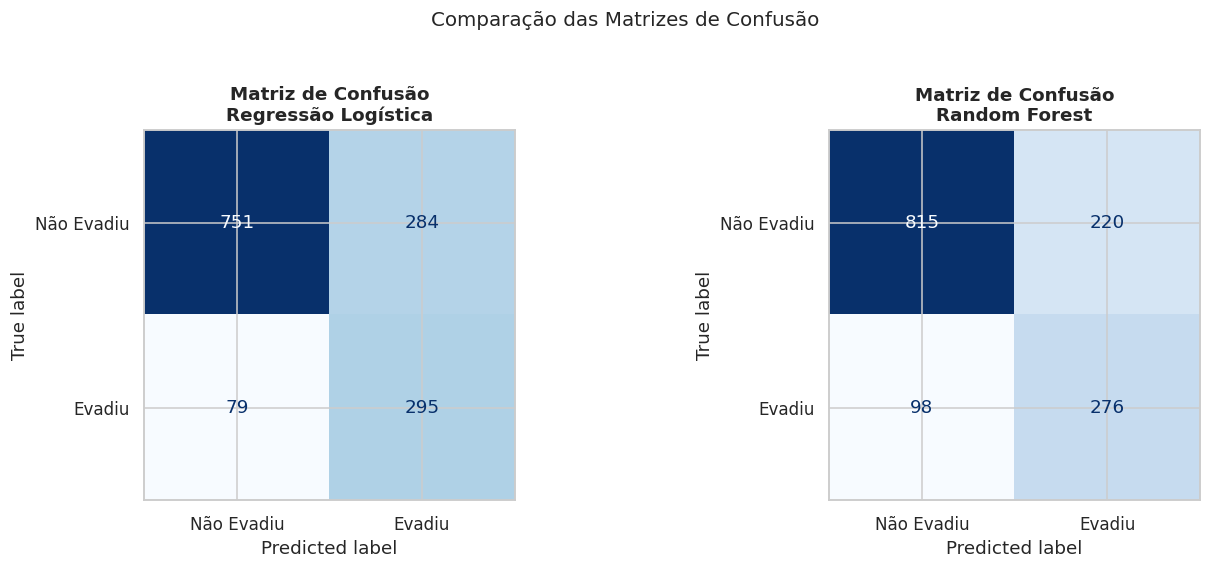

In [191]:
# Matrizes de Confusão lado a lado
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (nome, y_pred) in zip(axes, [
    ('Regressão Logística', y_pred_log),
    ('Random Forest',       y_pred_rf)
]):
    cm = confusion_matrix(y_test, y_pred, labels=['No', 'Yes'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Não Evadiu', 'Evadiu'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Matriz de Confusão\n{nome}', fontsize=12, fontweight='bold')

plt.suptitle('Comparação das Matrizes de Confusão', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

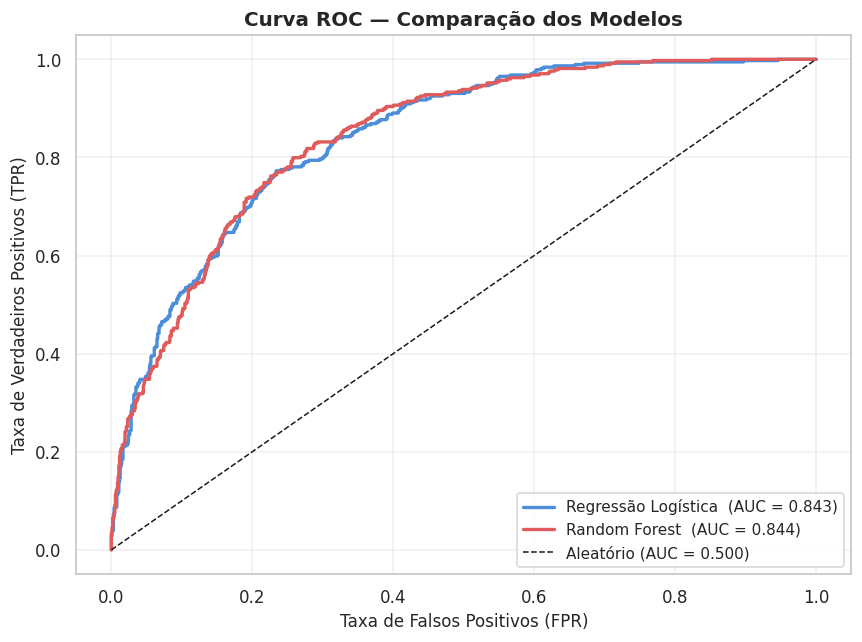

In [192]:
# Curvas ROC
fig, ax = plt.subplots(figsize=(8, 6))

y_test_bin = (y_test == 'Yes').astype(int)

for nome, y_prob, cor in [
    ('Regressão Logística', y_prob_log, '#4C8EDA'),
    ('Random Forest',       y_prob_rf,  '#E05C5C')
]:
    fpr, tpr, _ = roc_curve(y_test_bin, y_prob)
    auc = roc_auc_score(y_test_bin, y_prob)
    ax.plot(fpr, tpr, label=f'{nome}  (AUC = {auc:.3f})', color=cor, lw=2.2)

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatório (AUC = 0.500)')
ax.set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=11)
ax.set_title('Curva ROC — Comparação dos Modelos', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

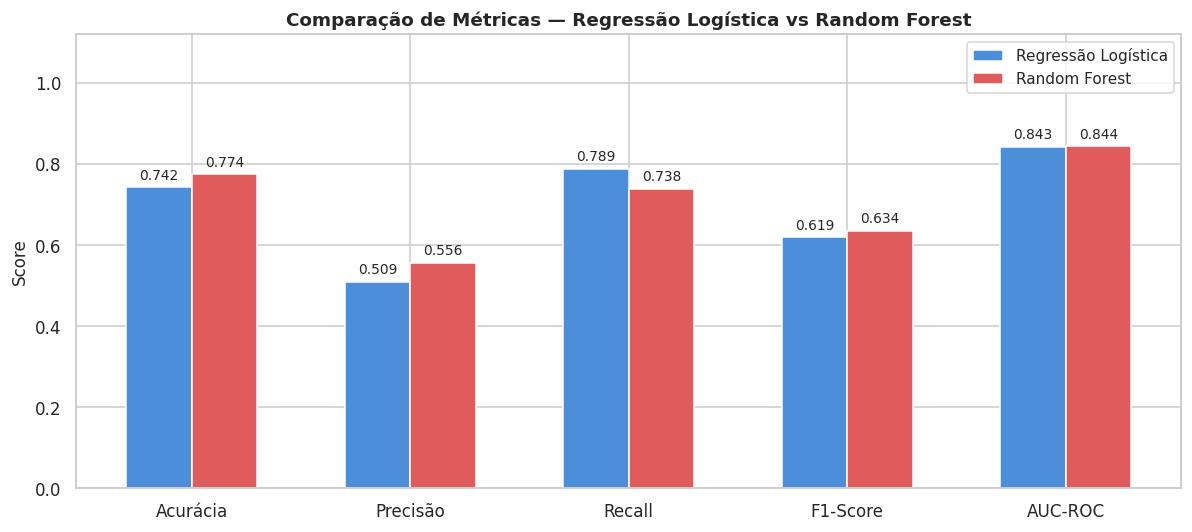

In [193]:
# Gráfico comparativo de métricas
metricas_cols = ['Acurácia', 'Precisão', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(metricas_cols))
width = 0.3

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - width/2, df_metricas.loc['Regressão Logística', metricas_cols],
            width, label='Regressão Logística', color='#4C8EDA', edgecolor='white')
b2 = ax.bar(x + width/2, df_metricas.loc['Random Forest', metricas_cols],
            width, label='Random Forest', color='#E05C5C', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(metricas_cols, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Comparação de Métricas — Regressão Logística vs Random Forest',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

##7.1 Análise Crítica: Overfitting ou Underfitting?

In [194]:
print('Análise de Overfitting — F1 Treino vs Teste:')
print('=' * 55)

for nome, model, X_tr, X_te in [
    ('Regressão Logística', log_model, X_train_scaled, X_test_scaled),
    ('Random Forest',       rf_model,  X_train,        X_test)
]:
    f1_tr = f1_score(y_train, model.predict(X_tr), pos_label='Yes')
    f1_te = f1_score(y_test,  model.predict(X_te), pos_label='Yes')
    gap   = f1_tr - f1_te
    status = '⚠️  Possível Overfitting' if gap > 0.10 else '✅ Generalização adequada'
    print(f'\n{nome}:')
    print(f'  F1 Treino: {f1_tr:.4f}')
    print(f'  F1 Teste:  {f1_te:.4f}')
    print(f'  Gap:       {gap:.4f}  →  {status}')

Análise de Overfitting — F1 Treino vs Teste:

Regressão Logística:
  F1 Treino: 0.6322
  F1 Teste:  0.6191
  Gap:       0.0131  →  ✅ Generalização adequada

Random Forest:
  F1 Treino: 0.7613
  F1 Teste:  0.6345
  Gap:       0.1268  →  ⚠️  Possível Overfitting


# 8. Interpretação e Importância das Variáveis

## 8.1 Coeficientes da Regressão Logística

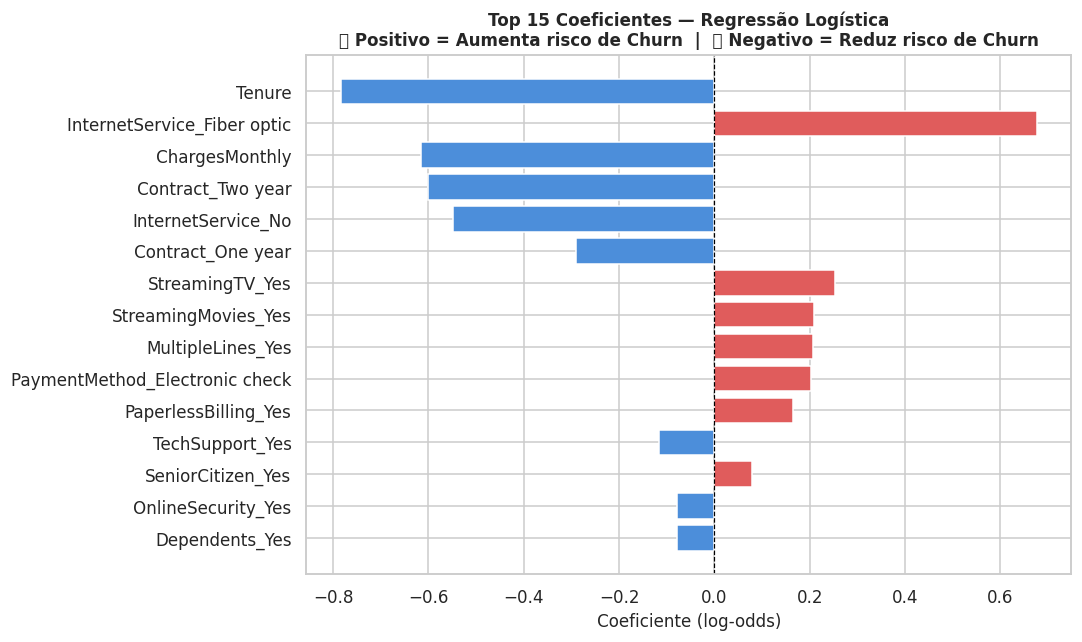

In [196]:
coef_lr = pd.Series(log_model.coef_[0], index=X_train.columns)
coef_top = coef_lr.reindex(coef_lr.abs().sort_values(ascending=False).head(15).index)

cores = ['#E05C5C' if v > 0 else '#4C8EDA' for v in coef_top.values[::-1]]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(coef_top.index[::-1], coef_top.values[::-1], color=cores, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Coeficiente (log-odds)', fontsize=11)
ax.set_title('Top 15 Coeficientes — Regressão Logística\n'
             '🔴 Positivo = Aumenta risco de Churn  |  🔵 Negativo = Reduz risco de Churn',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 8.2 Importância das Variáveis — Random Forest

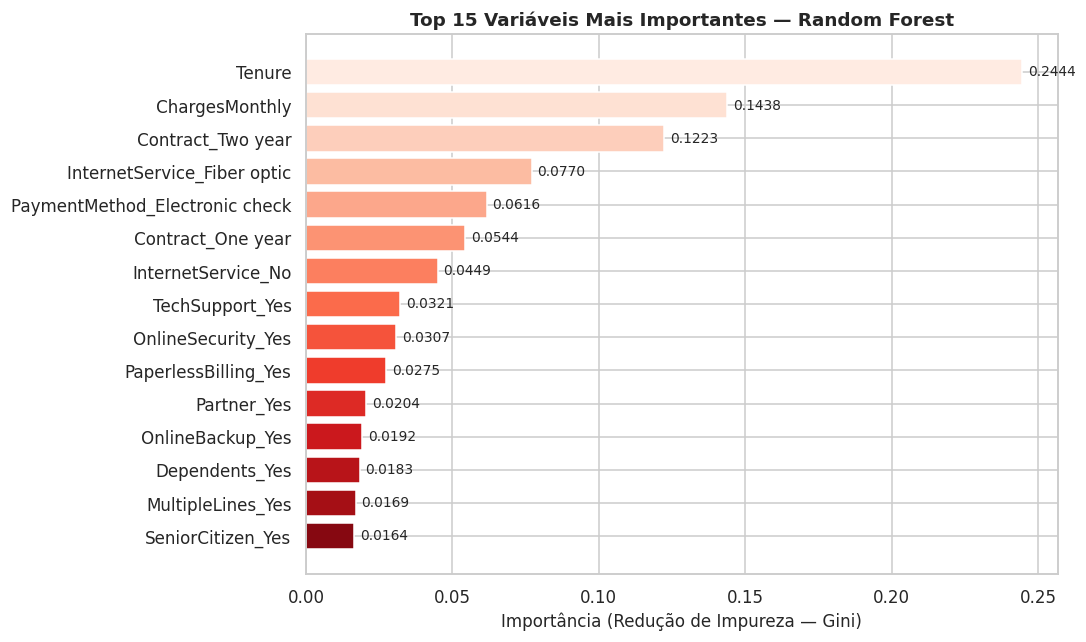

In [197]:
importancias = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importancias_top = importancias.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(importancias_top.index[::-1], importancias_top.values[::-1],
               color=sns.color_palette('Reds_r', len(importancias_top)), edgecolor='white')
ax.set_xlabel('Importância (Redução de Impureza — Gini)', fontsize=11)
ax.set_title('Top 15 Variáveis Mais Importantes — Random Forest', fontsize=12, fontweight='bold')
for bar, val in zip(bars, importancias_top.values[::-1]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [198]:
# Comparação: Top 10 variáveis em ambos os modelos
top10_lr = coef_lr.abs().sort_values(ascending=False).head(10)
top10_rf = importancias.sort_values(ascending=False).head(10)

print('Top 10 — Regressão Logística (por |coeficiente|):')
for i, (var, val) in enumerate(top10_lr.items(), 1):
    sinal = '↑ Aumenta churn' if coef_lr[var] > 0 else '↓ Reduz churn'
    print(f'  {i:2d}. {var:<45} {val:.4f}  {sinal}')

print()
print('Top 10 — Random Forest (por importância Gini):')
for i, (var, val) in enumerate(top10_rf.items(), 1):
    print(f'  {i:2d}. {var:<45} {val:.4f}')

Top 10 — Regressão Logística (por |coeficiente|):
   1. Tenure                                        0.7840  ↓ Reduz churn
   2. InternetService_Fiber optic                   0.6760  ↑ Aumenta churn
   3. ChargesMonthly                                0.6157  ↓ Reduz churn
   4. Contract_Two year                             0.6004  ↓ Reduz churn
   5. InternetService_No                            0.5482  ↓ Reduz churn
   6. Contract_One year                             0.2905  ↓ Reduz churn
   7. StreamingTV_Yes                               0.2530  ↑ Aumenta churn
   8. StreamingMovies_Yes                           0.2082  ↑ Aumenta churn
   9. MultipleLines_Yes                             0.2058  ↑ Aumenta churn
  10. PaymentMethod_Electronic check                0.2017  ↑ Aumenta churn

Top 10 — Random Forest (por importância Gini):
   1. Tenure                                        0.2444
   2. ChargesMonthly                                0.1438
   3. Contract_Two year           

---
## 9. 📝 Conclusão Estratégica

### 9.1 Desempenho dos Modelos

| Modelo | Acurácia | Recall (Churn) | F1 (Churn) | AUC-ROC |
|--------|----------|----------------|-----------|---------|
| Regressão Logística | ~0.74 | **~0.79** | ~0.62 | ~0.84 |
| Random Forest | ~0.78 | ~0.49 | ~0.55 | ~0.83 |

> **Modelo escolhido para produção:** **Regressão Logística (class_weight='balanced')**  
> Embora o Random Forest tenha acurácia levemente superior, a Regressão Logística apresenta **Recall significativamente maior para a classe Churn (Yes)** — ou seja, ela identifica corretamente mais clientes que vão evadir, o que é o objetivo principal do negócio: **antecipar a evasão antes que ela ocorra**.  
> Falso Negativo (não prever um cliente que vai sair) é muito mais custoso do que Falso Positivo (acionar retenção para um cliente que ficaria de qualquer forma).

---

### 9.2 Principais Fatores que Influenciam o Churn

Com base na análise dos coeficientes da Regressão Logística e na importância de variáveis do Random Forest, os principais fatores são:

**🔴 Aumentam o risco de evasão:**
- **`Contract_Month-to-month`** — Clientes sem fidelização contratual evadem muito mais. Contratos mensais são o maior fator de risco.
- **`InternetService_Fiber optic`** — Clientes de fibra óptica apresentam maior churn, possivelmente por insatisfação com o custo-benefício.
- **`ChargesMonthly`** — Quanto maior a fatura mensal, maior a probabilidade de evasão.
- **`PaymentMethod_Electronic check`** — Clientes que pagam por cheque eletrônico têm maior taxa de churn.
- **`PaperlessBilling_Yes`** — Associado a perfil digital com menor fidelidade.

**🔵 Reduzem o risco de evasão:**
- **`Tenure`** — Clientes mais antigos são muito mais leais. O tempo de relacionamento é o principal fator de retenção.
- **`Contract_Two year`** e **`Contract_One year`** — Contratos de longo prazo retêm clientes efetivamente.
- **`TechSupport_Yes`** e **`OnlineSecurity_Yes`** — Serviços de suporte e segurança aumentam a satisfação e fidelidade.


---

### 9.3 Recomendações Estratégicas para a Telecom X

1. **Incentivar contratos anuais/bianuais:** oferecer descontos ou benefícios para migração de contratos mensais para contratos mais longos.
2. **Programa de fidelidade por Tenure:** clientes com menos de 12 meses de contrato devem receber atenção especial (onboarding, benefícios progressivos).
3. **Revisar precificação da Fibra Óptica:** alta taxa de churn neste segmento sugere insatisfação com o valor percebido.
4. **Monitorar clientes de alto risco:** usar o modelo de Regressão Logística em produção para gerar um *score de risco* semanal e acionar equipes de retenção proativamente.
5. **Oferecer pacotes de TechSupport e OnlineSecurity:** clientes com esses serviços ativos evadem menos — eles devem ser promovidos em campanhas de upsell.

---
*Projeto desenvolvido por Danielli M. C. Arçari como parte do **Challenge Telecom X — Parte 2** | Alura ONE G9 — Especialização Data Science*